In [1]:
import pandas as pd
import numpy as np

# 1. Load dataset orders
df_orders = pd.read_csv('../data/archive/olist_orders_dataset.csv')

# 2. Cek 5 baris pertama data
print("--- 5 Data Teratas ---")
display(df_orders.head())

# 3. Cek tipe data dan jumlah baris/kolom
print("\n--- Informasi Struktur Data ---")
df_orders.info()

# 4. Cek jumlah data yang kosong (Missing Values)
print("\n--- Jumlah Missing Values per Kolom ---")
print(df_orders.isnull().sum())

--- 5 Data Teratas ---


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



--- Informasi Struktur Data ---
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB

--- Jumlah Missing Values per Kolom ---
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier

In [2]:
# 1. Mengubah tipe data kolom tanggal dari string ke datetime
datetime_columns = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date'
]

for col in datetime_columns:
    df_orders[col] = pd.to_datetime(df_orders[col])

# 2. Cek apakah tipe data sudah berubah
print("--- Cek Tipe Data Baru ---")
print(df_orders[datetime_columns].dtypes)

# 3. Membuktikan Hipotesis: Kenapa 'order_delivered_customer_date' kosong?
print("\n--- Status Pesanan yang Tanggal Pengirimannya Kosong ---")
null_delivery = df_orders[df_orders['order_delivered_customer_date'].isnull()]
print(null_delivery['order_status'].value_counts())

--- Cek Tipe Data Baru ---
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

--- Status Pesanan yang Tanggal Pengirimannya Kosong ---
order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64


In [3]:
# 1. Hapus data anomali delivered tapi tanggal pengiriman kosong
clean_condition = ~((df_orders['order_status'] == 'delivered') & (df_orders['order_delivered_customer_date'].isnull()))
df_orders = df_orders[clean_condition]

# 2. Bikin kolom baru: 'delivery_time_days' 
# Menghitung selisih hari antara barang diterima pembeli dengan waktu pembelian
df_orders['delivery_time_days'] = (df_orders['order_delivered_customer_date'] - df_orders['order_purchase_timestamp']).dt.days

# 3. Cek performa logistik: Berapa rata-rata lama pengiriman berdasarkan status
print("--- Rata-rata Lama Pengiriman (Hari) ---")
print(f"Rata-rata pengiriman keseluruhan: {df_orders['delivery_time_days'].mean():.1f} hari")

# 4. Cek data yang sudah punya kolom baru
display(df_orders[['order_id', 'order_status', 'delivery_time_days']].head())

--- Rata-rata Lama Pengiriman (Hari) ---
Rata-rata pengiriman keseluruhan: 12.1 hari


,order_id,order_status,delivery_time_days
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,13.0
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2.0


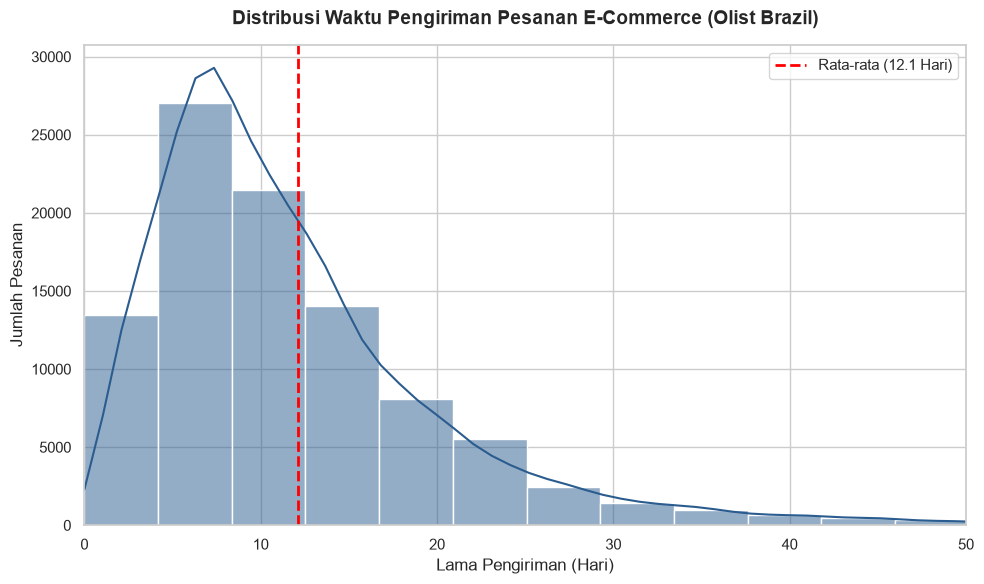

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Histogram untuk kolom 'delivery_time_days'
# Filter data pesanan yang sukses saja (delivered)
df_delivered = df_orders[df_orders['order_status'] == 'delivered']
sns.histplot(data=df_delivered, x='delivery_time_days', bins=50, kde=True, color='#2b5c8f')

# 2. Garis rata-rata (12.1 hari) sebagai titik acuan bisnis
avg_days = df_delivered['delivery_time_days'].mean()
plt.axvline(avg_days, color='red', linestyle='--', linewidth=2, label=f'Rata-rata ({avg_days:.1f} Hari)')

# 3. Beri Judul dan Label yang informatif
plt.title('Distribusi Waktu Pengiriman Pesanan E-Commerce (Olist Brazil)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Lama Pengiriman (Hari)', fontsize=12)
plt.ylabel('Jumlah Pesanan', fontsize=12)
plt.xlim(0, 50) # Membatasi sampai 50 hari akibat outlier
plt.legend()

# 4. Tampilkan grafik
plt.tight_layout()
plt.show()

In [ ]:
from sqlalchemy import create_engine, text

# 1. Setup ke MySQL
engine = create_engine('mysql+pymysql://root:@localhost:3306/')

# 2. Buat database baru menggunakan fungsi text()
with engine.connect() as conn:
    conn.execute(text("CREATE DATABASE IF NOT EXISTS olist_ecommerce"))
    conn.commit()

# 3. Hubungkan engine langsung ke database baru tersebut
engine = create_engine('mysql+pymysql://root:@localhost:3306/olist_ecommerce')

# 4. Pindahkan DataFrame df_orders ke MySQL menjadi tabel bernama 'orders'
print("Sedang mengimport data orders ke MySQL...")
df_orders.to_sql(name='orders', con=engine, if_exists='replace', index=False)
print("Selamat! Tabel 'orders' berhasil di-import ke MySQL!")

Sedang mengimport data orders ke MySQL...
Selamat! Tabel 'orders' berhasil di-import ke MySQL!
